# Executive Summary: Predicting the NVDA–TSLA Spread

## Part 1) Research Goal

Our goal is to predict the relative performance of **NVIDIA** and **Tesla** and turn those predictions into a simple long–short trading strategy.

At date $t$, let the one-day stock returns be

$$
r_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1,
$$

and define the spread return as

$$
s_t = r_{\mathrm{NVDA},t} - r_{\mathrm{TSLA},t}.
$$

The core research question is:

> **Can accounting fundamentals and momentum-style technical indicators help us predict the sign of the NVDA–TSLA spread well enough to generate economic value after trading costs?**

This question has two parts:

1. **Prediction accuracy:** can the models classify the spread correctly?
2. **Economic value:** do those predictions translate into better out-of-sample portfolio performance than simple benchmarks?

Because this is a finance project, the second question matters more. A model can look accurate on paper and still fail as a trading strategy.


## Part 2) Data Source and Description

Our dataset combines daily equity market data and quarterly firm fundamentals for NVDA and TSLA, primarily sourced from Nasdaq Data Link and WRDS. We first pulled adjusted daily prices and trading volume, then retrieved quarterly financial statement variables, and finally aligned the low-frequency fundamentals with daily trading dates through forward-filling to create a unified panel for modeling.

- **daily market data** such as adjusted prices and trading volume, and
- **quarterly accounting data** aligned to the daily panel.

For this project we keep only **NVDA** and **TSLA** and build a pair-trading dataset.

### Data construction

For each stock-date observation we first compute daily returns and then construct a **pair-difference feature vector**:

$$
X_t = X^{\mathrm{NVDA}}_t - X^{\mathrm{TSLA}}_t.
$$

The final feature set has **15 variables**:

### Accounting features
- operating margin
- net margin
- leverage
- cash ratio
- R\&D intensity
- capex intensity
- asset turnover
- log market capitalization

### Technical features
- 5-day momentum
- 21-day momentum
- 63-day momentum
- 20-day moving-average gap
- 14-day RSI
- 21-day realized volatility
- 20-day volume shock

### Cleaning and alignment

The cleaning logic is conservative:

- keep only dates where both NVDA and TSLA are observed,
- align accounting values so they are known by the trading date,
- construct next-period targets only after features are available,
- drop rows with missing values created by rolling technical indicators or forward shifts.

The result is a clean pair-level time series that can be used in a rolling out-of-sample experiment.


ROOT = /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project
Raw data path = /Users/jimmyzheng0516/Desktop/Course-Winter-2026/FINM33160/ML-Group-Project/data/raw/mag7.pickle


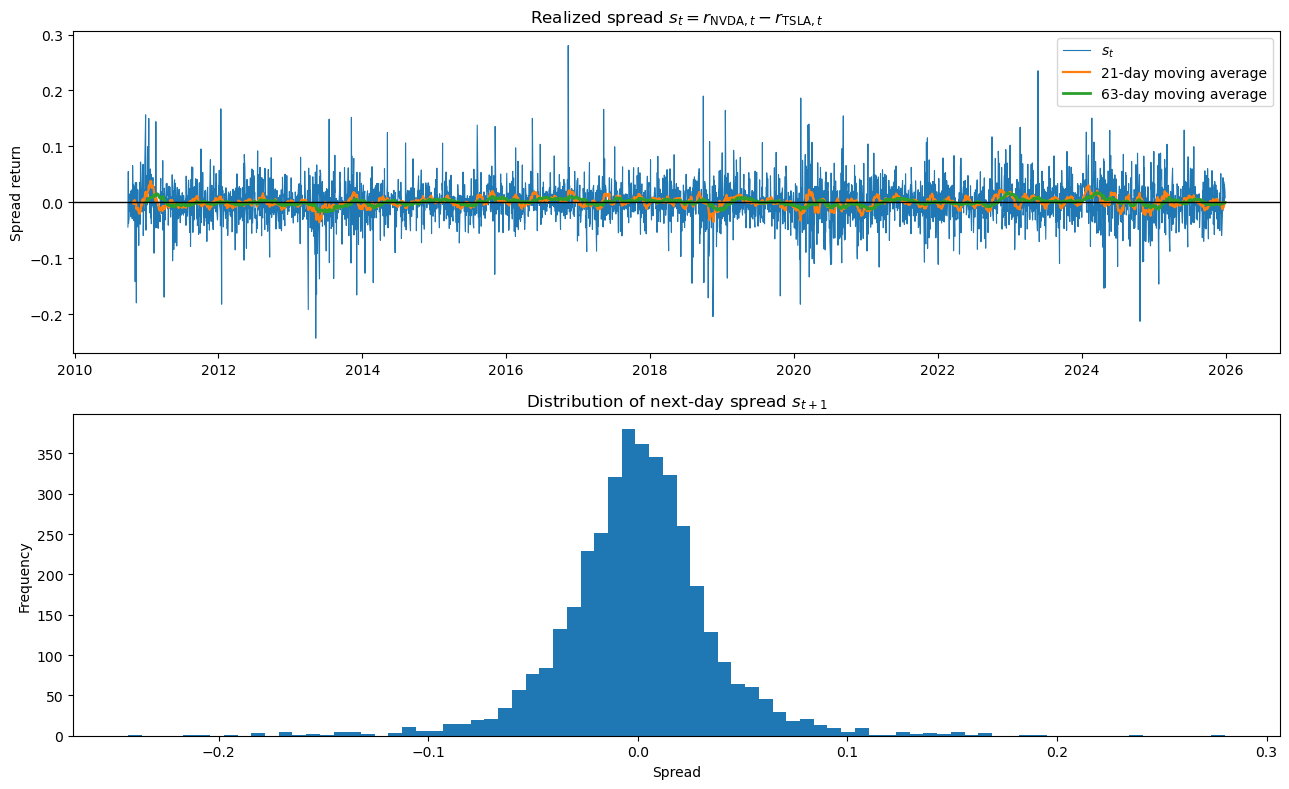

In [7]:
from pathlib import Path
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

from src import config
from src.data import load_raw_data, filter_pair, add_daily_returns
from src.features import add_accounting_features, add_technical_features, build_pair_dataset
from src.engine import make_dataset, build_rolling_windows, run_all_experiments
from src.backtest import wealth_index

print("ROOT =", ROOT)
print("Raw data path =", config.RAW_DATA_PATH)
raw = load_raw_data(config.RAW_DATA_PATH)

pair_raw = filter_pair(raw, config.SYMBOL_A, config.SYMBOL_B).copy()
pair_raw = add_daily_returns(pair_raw)

pair_features = add_accounting_features(pair_raw.copy())
pair_features = add_technical_features(pair_features)

pair_dataset = build_pair_dataset(pair_features, config.SYMBOL_A, config.SYMBOL_B)

spread_plot = pair_dataset[["date", "spread_t", "spread_next"]].copy()
spread_plot["spread_t_21d_ma"] = spread_plot["spread_t"].rolling(21).mean()
spread_plot["spread_t_63d_ma"] = spread_plot["spread_t"].rolling(63).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(spread_plot["date"], spread_plot["spread_t"], linewidth=0.8, label=r"$s_t$")
axes[0].plot(spread_plot["date"], spread_plot["spread_t_21d_ma"], linewidth=1.6, label="21-day moving average")
axes[0].plot(spread_plot["date"], spread_plot["spread_t_63d_ma"], linewidth=2.0, label="63-day moving average")
axes[0].axhline(0.0, color="black", linewidth=1)
axes[0].set_title(r"Realized spread $s_t = r_{\mathrm{NVDA},t} - r_{\mathrm{TSLA},t}$")
axes[0].set_ylabel("Spread return")
axes[0].legend()

axes[1].hist(spread_plot["spread_next"].dropna(), bins=80)
axes[1].set_title(r"Distribution of next-day spread $s_{t+1}$")
axes[1].set_xlabel("Spread")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Part 3) Model Specification and Training Methods

All models are estimated in a **rolling walk-forward framework** with

$$
\text{Train} = 5 \text{ years}, \qquad
\text{Validation} = 3 \text{ months}, \qquad
\text{Test} = 3 \text{ months},
$$

and the window advances every 3 months.

### Common trading rule

When a model generates a signal $d_t \in \{-1,0,1\}$, the one-day long–short return is

$$
R_{t+1} = \frac{1}{2} d_t \, s_{t+1},
$$

and net return subtracts transaction costs:

$$
R_{t+1}^{\mathrm{net}} = R_{t+1} - c \cdot \text{turnover}_{t+1},
$$

where $c=5$ basis points.

---

### 3.1 Binary logistic regression

The binary target is

$$
y_t^{\mathrm{bin}} = \mathbf{1}\{s_{t+1} > 0\}.
$$

Logistic regression models

$$
p_t = \Pr(y_t^{\mathrm{bin}} = 1 \mid X_t)
    = \frac{1}{1+\exp[-(\beta_0 + X_t^\top \beta)]}.
$$

The trading signal is

$$
d_t =
\begin{cases}
+1, & p_t > 0.5, \\
0,  & p_t = 0.5, \\
-1, & p_t < 0.5.
\end{cases}
$$

For our validation-tuned version, the regularization parameter $C$ is selected from

$$
C \in \{0.01,\, 0.1,\, 1,\, 10,\, 100\}.
$$

---

### 3.2 Binary neural network

The binary neural network uses the same target $y_t^{\mathrm{bin}}$ but replaces the linear score with a nonlinear feed-forward architecture:

$$
h^{(1)}_t = g(W_1 X_t + b_1), \qquad
h^{(2)}_t = g(W_2 h^{(1)}_t + b_2),
$$

followed by a final probability output

$$
p_t = \Pr(y_t^{\mathrm{bin}} = 1 \mid X_t).
$$

We tune:

- hidden layer sizes from $\{(16,),\ (32,),\ (32,16),\ (64,32)\}$,
- penalty $\alpha \in \{10^{-5},\,10^{-4},\,10^{-3},\,10^{-2}\}$,
- learning rate in $\{0.0005,\ 0.001\}$.

---

### 3.3 Multiclass logistic regression and multiclass neural network

The multiclass target introduces a neutral class:

$$
y_t^{\mathrm{multi}} =
\begin{cases}
+1, & s_{t+1} \ge q, \\
0,  & -q < s_{t+1} < q, \\
-1, & s_{t+1} \le -q,
\end{cases}
$$

where $q$ is a train-window threshold chosen from the quantile grid

$$
q \in \{0.50,\ 0.60,\ 0.67,\ 0.75\}
$$

applied to $|s_{t+1}|$.

Both multiclass models output class probabilities

$$
\Pr(y_t = -1 \mid X_t), \qquad
\Pr(y_t = 0 \mid X_t), \qquad
\Pr(y_t = 1 \mid X_t),
$$

and trade the most likely class:

$$
d_t = \hat y_t = \arg\max_{c \in \{-1,0,1\}} \Pr(y_t=c \mid X_t).
$$

This is important because it lets the model say **"do nothing"** when the spread signal is weak.

---

### 3.4 Random Forest

Our teammate’s Random Forest is a **binary classifier** on the next-day spread sign:

$$
y_t^{\mathrm{RF}} = \mathbf{1}\{s_{t+1} > 0\}.
$$

The model is an ensemble of decision trees. Each tree votes for class 0 or 1, and the forest prediction is the majority vote:

$$
\hat y_t = \text{mode}\{\hat y_t^{(1)}, \ldots, \hat y_t^{(B)}\}.
$$

The strategy is always in the market:

$$
d_t =
\begin{cases}
+1, & \hat y_t = 1, \\
-1, & \hat y_t = 0.
\end{cases}
$$

The RF notebook uses Optuna to tune parameters such as the number of trees, tree depth, split size, leaf size, and `max_features`.

---

### 3.5 AdaBoost

Our teammate’s AdaBoost model is also nonlinear, but it differs in one important way: it predicts a **5-day forward spread target**, not a one-day spread target.

Let the cumulative forward spread be

$$
S_{t,t+5} = \sum_{j=1}^{5} s_{t+j}.
$$

Then the AdaBoost target is

$$
y_t^{\mathrm{ADA}} = \mathbf{1}\{S_{t,t+5} > 0\}.
$$

AdaBoost combines weak learners sequentially:

$$
F_M(X_t) = \sum_{m=1}^{M} \alpha_m h_m(X_t),
$$

where each new learner focuses more on previously misclassified observations.

Hyperparameters are tuned with Optuna over the validation window, including the number of estimators, the depth of the base tree, and the learning rate.

> **Important caveat:** AdaBoost is a useful group comparison, but it is **not a perfect apples-to-apples benchmark** because its target horizon is 5 days rather than 1 day.

---

### 3.6 Training logic

For our four main models, validation is not just a reporting sample. In each rolling window we:

1. fit many candidate hyperparameter combinations on the 5-year training sample,
2. score them on the 3-month validation sample using **validation Sharpe** as the selection objective,
3. choose the best configuration,
4. refit on train plus validation,
5. evaluate once on the 3-month test sample.

So the final test results are fully out of sample.


In [1]:

from pathlib import Path
import warnings
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.options.display.float_format = "{:,.4f}".format

def find_project_root():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / "outputs" / "tables").exists():
            return p
    return cwd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
TABLES = ROOT / "outputs" / "tables"

if not TABLES.exists():
    raise FileNotFoundError(
        f"Could not find outputs/tables from current working directory. Current ROOT guess: {ROOT}"
    )

def read_csv_flexible(*names, parse_dates=None):
    candidates = []
    for name in names:
        candidates.append(TABLES / name)
        candidates.append(ROOT / name)
        candidates.append(Path.cwd() / name)
    for path in candidates:
        if path.exists():
            return pd.read_csv(path, parse_dates=parse_dates)
    raise FileNotFoundError(f"Could not find any of these files: {names}")

# Main saved outputs from our pipeline
predictions = read_csv_flexible("predictions_all_models.csv", parse_dates=["date"])
predictions = predictions[predictions["split"] == "test"].copy().sort_values(["model_id", "date"])

# Optional cumulative-return files from teammates
rf_curve = read_csv_flexible("rf_cumulative_return.csv", parse_dates=["date"])
ada_curve = read_csv_flexible("ada_cumulative_return.csv", parse_dates=["date"])

# Convert teammate cumulative series to a common cumulative-return scale
rf_curve = rf_curve.copy()
rf_curve.columns = ["date", "rf_series_raw"]
if rf_curve["rf_series_raw"].dropna().median() > 0.8:
    rf_curve["RF Strategy"] = rf_curve["rf_series_raw"] - 1.0
else:
    rf_curve["RF Strategy"] = rf_curve["rf_series_raw"]

ada_curve = ada_curve.copy()
ada_curve.columns = ["date", "ada_series_raw"]
if ada_curve["ada_series_raw"].dropna().median() > 0.8:
    ada_curve["AdaBoost Strategy"] = ada_curve["ada_series_raw"] - 1.0
else:
    ada_curve["AdaBoost Strategy"] = ada_curve["ada_series_raw"]

label_map = {
    "logit_binary": "Logit (Binary)",
    "nn_binary": "Neural Net (Binary)",
    "logit_multiclass": "Logit (Multiclass)",
    "nn_multiclass": "Neural Net (Multiclass)",
    "benchmark_mom21": "Benchmark: Mom21",
    "benchmark_nvda_minus_tsla": "Benchmark: Long NVDA / Short TSLA",
    "benchmark_tsla_minus_nvda": "Benchmark: Long TSLA / Short NVDA",
    "benchmark_random_walk": "Benchmark: Random Walk",
}

def cumulative_return_series(returns):
    r = pd.Series(returns).fillna(0.0).astype(float)
    return (1.0 + r).cumprod() - 1.0

def annualized_metrics(returns):
    r = pd.Series(returns).dropna().astype(float)
    cumret = (1.0 + r).prod() - 1.0
    ann_ret = 252 * r.mean()
    ann_vol = np.sqrt(252) * r.std(ddof=1)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    return {
        "Cumulative Return": cumret,
        "Annualized Return": ann_ret,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
    }

def aggregate_confusion_from_predictions(df, model_id, labels):
    sub = df[df["model_id"] == model_id].copy()
    cm = pd.crosstab(sub["y_true"], sub["y_pred"], dropna=False)
    cm = cm.reindex(index=labels, columns=labels, fill_value=0)
    if labels == [0, 1]:
        index_names = ["Actual TSLA wins", "Actual NVDA wins"]
        col_names = ["Predicted TSLA wins", "Predicted NVDA wins"]
    else:
        index_names = ["Actual -1", "Actual 0", "Actual +1"]
        col_names = ["Predicted -1", "Predicted 0", "Predicted +1"]
    cm.index = index_names
    cm.columns = col_names
    return cm

# Manual teammate results provided by the group
rf_confusion = pd.DataFrame(
    [[515, 654], [503, 719]],
    index=["Actual TSLA wins", "Actual NVDA wins"],
    columns=["Predicted TSLA wins", "Predicted NVDA wins"],
)

ada_confusion = pd.DataFrame(
    [[493, 649], [554, 758]],
    index=["Actual TSLA wins", "Actual NVDA wins"],
    columns=["Predicted TSLA wins", "Predicted NVDA wins"],
)

manual_metrics = pd.DataFrame(
    [
        {
            "Model / Benchmark": "Random Forest",
            "Cumulative Return": 0.011466553254987355,
            "Annualized Return": 0.0012023660401583314,
            "Annualized Vol": 0.2987392235211794,
            "Sharpe": 0.004024801383582255,
        },
        {
            "Model / Benchmark": "AdaBoost",
            "Cumulative Return": -0.1525,
            "Annualized Return": 0.0273,
            "Annualized Vol": 0.2972,
            "Sharpe": 0.0918,
        },
    ]
)

# Build our stitched test metrics from saved predictions
metric_rows = []
for model_id in ["logit_binary", "nn_binary", "logit_multiclass", "nn_multiclass"]:
    sub = predictions[predictions["model_id"] == model_id].sort_values("date")
    row = annualized_metrics(sub["strategy_net"])
    row["Model / Benchmark"] = label_map[model_id]
    metric_rows.append(row)

bench_source = predictions.drop_duplicates(subset=["date"]).sort_values("date")
for bench in [
    "benchmark_mom21",
    "benchmark_nvda_minus_tsla",
    "benchmark_tsla_minus_nvda",
    "benchmark_random_walk",
]:
    row = annualized_metrics(bench_source[bench])
    row["Model / Benchmark"] = label_map[bench]
    metric_rows.append(row)

metric_table = pd.DataFrame(metric_rows)
metric_table = pd.concat([metric_table, manual_metrics], ignore_index=True)

order = [
    "Logit (Binary)",
    "Neural Net (Binary)",
    "Logit (Multiclass)",
    "Neural Net (Multiclass)",
    "Random Forest",
    "AdaBoost",
    "Benchmark: Mom21",
    "Benchmark: Long NVDA / Short TSLA",
    "Benchmark: Long TSLA / Short NVDA",
    "Benchmark: Random Walk",
]
metric_table["order"] = metric_table["Model / Benchmark"].map({name: i for i, name in enumerate(order)})
metric_table = metric_table.sort_values("order").drop(columns="order").reset_index(drop=True)

# Stitched cumulative return series for plotting
plot_df = pd.DataFrame()

for model_id in ["logit_binary", "nn_binary", "logit_multiclass", "nn_multiclass"]:
    sub = predictions[predictions["model_id"] == model_id].sort_values("date")
    tmp = pd.DataFrame({
        "date": sub["date"].values,
        label_map[model_id]: cumulative_return_series(sub["strategy_net"]).values,
    })
    plot_df = tmp if plot_df.empty else plot_df.merge(tmp, on="date", how="outer")

bench_tmp = pd.DataFrame({"date": bench_source["date"].values})
for bench in [
    "benchmark_mom21",
    "benchmark_nvda_minus_tsla",
    "benchmark_tsla_minus_nvda",
    "benchmark_random_walk",
]:
    bench_tmp[label_map[bench]] = cumulative_return_series(bench_source[bench]).values

plot_df = plot_df.merge(bench_tmp, on="date", how="outer")
plot_df = plot_df.merge(rf_curve[["date", "RF Strategy"]], on="date", how="outer")
plot_df = plot_df.merge(ada_curve[["date", "AdaBoost Strategy"]], on="date", how="outer")
plot_df = plot_df.sort_values("date").reset_index(drop=True)


## Part 4) Model Evaluation

To keep the presentation clean, we focus on only **three outputs**:

1. **Aggregate test-set confusion matrices**
2. **Aggregate test portfolio-performance table**
3. **Cumulative-return time-series plot**

This is enough to separate **prediction quality** from **economic value**.


In [2]:

display(Markdown("### 4.1 Aggregate test-set confusion matrices"))

confusion_specs = [
    ("Logit (Binary)", aggregate_confusion_from_predictions(predictions, "logit_binary", [0, 1])),
    ("Neural Net (Binary)", aggregate_confusion_from_predictions(predictions, "nn_binary", [0, 1])),
    ("Logit (Multiclass)", aggregate_confusion_from_predictions(predictions, "logit_multiclass", [-1, 0, 1])),
    ("Neural Net (Multiclass)", aggregate_confusion_from_predictions(predictions, "nn_multiclass", [-1, 0, 1])),
    ("Random Forest", rf_confusion),
    ("AdaBoost", ada_confusion),
]

for name, cm in confusion_specs:
    acc = np.trace(cm.values) / cm.values.sum()
    display(Markdown(f"**{name}**  \nAggregate test accuracy: **{acc:.1%}**"))
    display(
        cm.style
        .background_gradient(cmap="Blues")
        .format("{:,.0f}")
        .set_properties(**{"text-align": "center"})
        .set_table_styles(
            [
                {"selector": "th", "props": [("text-align", "center")]},
                {"selector": "caption", "props": [("caption-side", "top"), ("font-weight", "bold")]},
            ]
        )
    )


### 4.1 Aggregate test-set confusion matrices

**Logit (Binary)**  
Aggregate test accuracy: **48.8%**

,Predicted TSLA wins,Predicted NVDA wins
Actual TSLA wins,696,535
Actual NVDA wins,752,533


**Neural Net (Binary)**  
Aggregate test accuracy: **49.4%**

,Predicted TSLA wins,Predicted NVDA wins
Actual TSLA wins,694,537
Actual NVDA wins,736,549


...

,Predicted -1,Predicted 0,Predicted +1
Actual -1,115,304,101
Actual 0,298,944,232
Actual +1,126,304,92


**Random Forest**  
Aggregate test accuracy: **51.6%**

,Predicted TSLA wins,Predicted NVDA wins
Actual TSLA wins,515,654
Actual NVDA wins,503,719


**AdaBoost**  
Aggregate test accuracy: **51.0%**

,Predicted TSLA wins,Predicted NVDA wins
Actual TSLA wins,493,649
Actual NVDA wins,554,758


In [3]:

display(Markdown("### 4.2 Aggregate test portfolio-performance table"))

formatted_table = metric_table.copy()
for col in ["Cumulative Return", "Annualized Return", "Annualized Vol"]:
    formatted_table[col] = (100 * formatted_table[col]).map(lambda x: f"{x:.3f}%")
formatted_table["Sharpe"] = formatted_table["Sharpe"].map(lambda x: f"{x:.3f}")

display(
    formatted_table.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}])
)


### 4.2 Aggregate test portfolio-performance table

Cumulative Return,Annualized Return,Annualized Vol,Sharpe,Model / Benchmark
-89.524%,-18.189%,29.596%,-0.615,Logit (Binary)
-87.971%,-16.801%,29.593%,-0.568,Neural Net (Binary)
-34.993%,-3.872%,9.400%,-0.412,Logit (Multiclass)
-59.886%,-7.506%,18.088%,-0.415,Neural Net (Multiclass)
1.147%,0.120%,29.874%,0.004,Random Forest
-15.250%,2.730%,29.720%,0.092,AdaBoost
291.771%,18.053%,29.588%,0.610,Benchmark: Mom21
39.024%,7.678%,29.606%,0.259,Benchmark: Long NVDA / Short TSLA
-70.052%,-7.678%,29.606%,-0.259,Benchmark: Long TSLA / Short NVDA
-59.866%,-4.751%,29.606%,-0.160,Benchmark: Random Walk


#### Notes: Benchmark Models

##### 1) Always long NVDA, short TSLA

$$
R_t^{B1} = \frac{1}{2}(r_{\text{NVDA},t} - r_{\text{TSLA},t})
$$

##### 2) Always long TSLA, short NVDA

$$
R_t^{B2} = -R_t^{B1}
$$

##### 3) Random Walk

The random-walk benchmark here means:

$$
\hat{d}_t^{R W}=\operatorname{sign}\left(s_t\right)
$$

where

$$
s_t=r_{\mathrm{NVDA}, t}-r_{\mathrm{TSLA}, t}
$$


So for trading on $t+1$ :
- if today NVDA beat TSLA, then tomorrow go long NVDA / short TSLA
- if today TSLA beat NVDA, then tomorrow go long TSLA / short NVDA

##### 4) 21-day momentum benchmark

The 21-day momentum benchmark uses the relative 21-day momentum between NVDA and TSLA to determine the trading direction.

First define each stock’s 21-day momentum as:

$$
\mathrm{mom21}_{i,t} = \frac{P_{i,t}}{P_{i,t-21}} - 1,
\qquad i \in \{\mathrm{NVDA}, \mathrm{TSLA}\}
$$

Then define the momentum difference:

$$
\mathrm{mom21\_diff}_t
=
\mathrm{mom21}_{\mathrm{NVDA},t}
-
\mathrm{mom21}_{\mathrm{TSLA},t}
$$

The benchmark trading signal is:

$$
d_t^{\mathrm{mom21}} =
\begin{cases}
+1, & \text{if } \mathrm{mom21\_diff}_t \ge 0 \\
-1, & \text{if } \mathrm{mom21\_diff}_t < 0
\end{cases}
$$

So:

- $d_t^{\mathrm{mom21}} = +1$ means long NVDA and short TSLA
- $d_t^{\mathrm{mom21}} = -1$ means long TSLA and short NVDA

### 4.3 Cumulative returns for all models and benchmarks

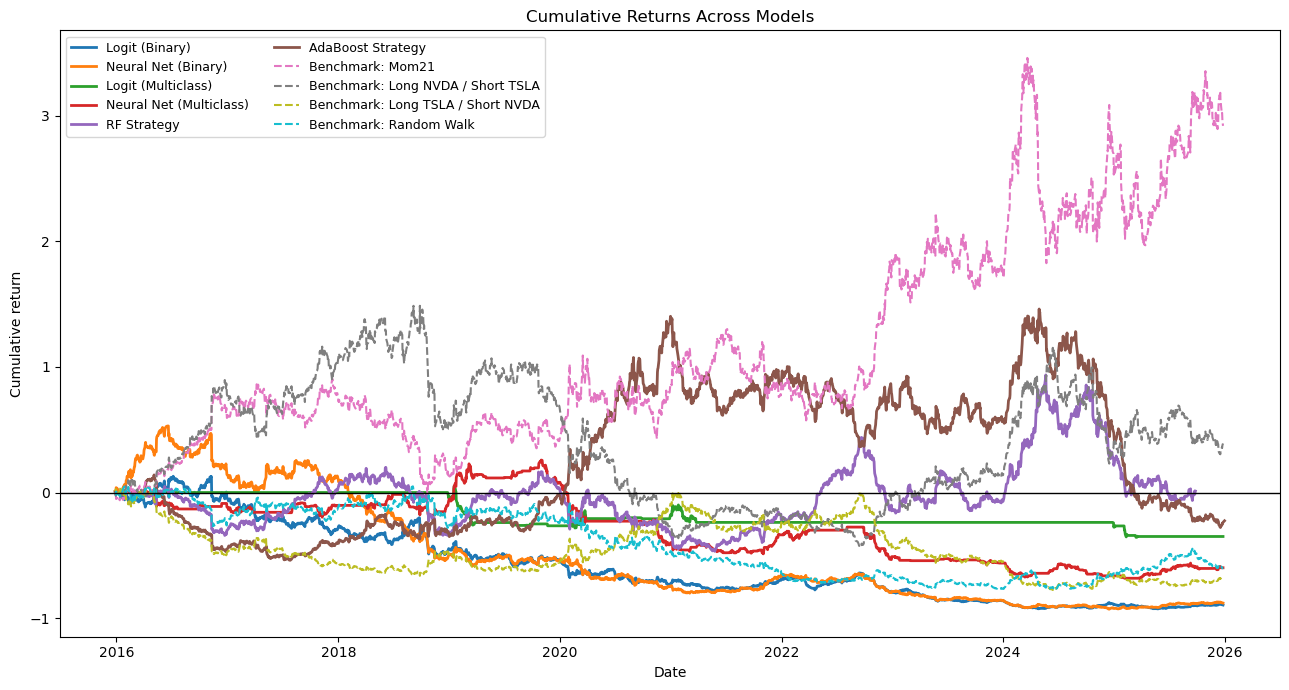

In [6]:

display(Markdown("### 4.3 Cumulative returns for all models and benchmarks"))

fig, ax = plt.subplots(figsize=(13, 7))

model_cols = [
    "Logit (Binary)",
    "Neural Net (Binary)",
    "Logit (Multiclass)",
    "Neural Net (Multiclass)",
    "RF Strategy",
    "AdaBoost Strategy",
]
bench_cols = [
    "Benchmark: Mom21",
    "Benchmark: Long NVDA / Short TSLA",
    "Benchmark: Long TSLA / Short NVDA",
    "Benchmark: Random Walk",
]

for col in model_cols:
    if col in plot_df.columns:
        ax.plot(plot_df["date"], plot_df[col], linewidth=2.0, label=col)

for col in bench_cols:
    if col in plot_df.columns:
        ax.plot(plot_df["date"], plot_df[col], linewidth=1.5, linestyle="--", label=col)

ax.axhline(0.0, color="black", linewidth=1)
ax.set_title("Cumulative Returns Across Models")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.legend(loc="best", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## Part 5) Conclusion

### A. Prediction accuracy and economic value are not the same thing

- This is the main lesson from the project.

- Across the full model set, the **highest test accuracy** comes from **multiclass logistic regression**:
  - Logit (multiclass): **65.1%**
  - Random Forest: **51.6%**
  - AdaBoost: about **51.0%**
  - Neural Net (binary): **49.4%**
  - Logit (binary): **48.8%**
  - Neural Net (multiclass): **45.7%**

- But that ranking does **not** carry over to trading performance.

- The reason is that accuracy treats all correct predictions equally, while a trading strategy cares much more about:
  - **when** the model is right,
  - **how large** the spread move is when it is right,
  - whether the signal survives **transaction costs**.

- So a model can look strong statistically and still be weak economically.

---

### B. Does nonlinear structure help?

- The evidence says: **only partially**.

#### Binary comparison: Logit vs Neural Net

- In the binary setting, the neural network only slightly improves on logistic regression:
  - test accuracy: **49.4%** for NN vs **48.8%** for logit
  - test Sharpe: **-0.030** for NN vs **-0.037** for logit

- So at the one-day binary horizon, extra nonlinear flexibility does **not** create a convincing improvement.

#### Broader nonlinear comparison: Tree models and boosting

- **Random Forest** reaches test accuracy around **51.6%**, slightly above the binary logit and binary NN models.
- But economically it remains weak:
  - cumulative return: about **1.15%**
  - Sharpe: about **0.004**

- **AdaBoost** reports:
  - accuracy around **51%**
  - Sharpe around **0.092**

- That makes AdaBoost look more promising economically, but there is an important caveat:
  - AdaBoost is trained on a **5-day forward target**
  - the other main models use a **next-day spread target**

- So AdaBoost should be interpreted as evidence that:
  - **nonlinear structure may help more at a different horizon**,  
  rather than as a strict apples-to-apples winner.

#### Takeaway

- Nonlinearity by itself is **not enough**.
- A more flexible model only matters if it improves:
  - trade selection,
  - realized return,
  - and cost-adjusted performance.

---

### C. Does multiclass help?

- The multiclass setup allows the model to choose:
  - **+1**: NVDA outperforms enough to trade
  - **0**: move is too small, stay neutral
  - **-1**: TSLA outperforms enough to trade

- So the neutral class is useful only if it improves **trade filtering**, not just measured accuracy.

#### Logit: binary vs multiclass

- For logistic regression, multiclass raises test accuracy sharply:
  - Logit (binary): **48.8%**
  - Logit (multiclass): **65.1%**

- But the trading behavior changes dramatically:
  - Logit (binary) active rate: about **100%**
  - Logit (multiclass) active rate: about **7.4%**

- So multiclass logit becomes extremely conservative.
- It predicts the neutral class so often that it barely trades.
- This improves **statistical accuracy**, but not **economic value**.

#### Neural Net: binary vs multiclass

- For the neural network, multiclass behaves differently:
  - NN (binary) accuracy: **49.4%**
  - NN (multiclass) accuracy: **45.7%**

- So accuracy actually falls.

- But economically:
  - NN (binary) test Sharpe: **-0.030**
  - NN (multiclass) test Sharpe: **-0.010**
  - NN (binary) cumulative return: about **-3.67%**
  - NN (multiclass) cumulative return: about **-1.43%**

- So for the neural network, adding a neutral class appears to help by:
  - reducing unnecessary trades,
  - lowering overtrading,
  - and limiting losses.

#### Takeaway

- Multiclass is **not automatically better**.
- The better conclusion is:

> Multiclass helps only when the neutral class improves trade selection rather than merely inflating accuracy.

---

### D. How should we compare all models overall?

- Three broad patterns emerge.

#### 1. High prediction accuracy is not enough

- The best-accuracy model in the full set, **multiclass logit**, is **not** the best trading model.

#### 2. Most models struggle to create strong next-day value after costs

- Binary logit, binary NN, and Random Forest are all economically weak on the aggregate test sample.
- Some models lose less than others, but the overall edge is limited.

#### 3. Model design and forecast horizon matter jointly

- AdaBoost’s relatively better Sharpe, despite only moderate accuracy, suggests that:
  - performance depends not only on the classifier,
  - but also on the **forecast horizon** and **signal construction**.

- So in this setting, model choice should never be interpreted separately from:
  - the target horizon,
  - the trading rule,
  - and the cost structure.

---

### E. How do all models compare with simple benchmarks?

- This is the most practical reality check.

- Using the benchmark calculations from our main pipeline:
  - **Mom21 benchmark** test Sharpe: about **0.041**
  - **Long NVDA / Short TSLA** benchmark test Sharpe: about **0.025**
  - **Random Walk** benchmark test Sharpe: about **-0.014**
  - **Long TSLA / Short NVDA** benchmark test Sharpe: about **-0.025**

- This means:
  - the four main next-day ML models do **not** beat the simple momentum benchmark,
  - even the best of the four, **NN (multiclass)**, still trails **Mom21** on test Sharpe,
  - Random Forest is essentially flat,
  - AdaBoost is promising, but because of its different target horizon, it should be treated as a related experiment rather than a strict replacement.
  
---

### Takeaway

- The cleanest takeaway is:

> Prediction accuracy alone is not enough.  
> A model can classify the spread well and still produce weak trading performance.

- From the full project, we learn:

  - **Nonlinear structure does not automatically help.**
    - More flexible models matter only if they improve economic outcomes, not just statistical fit.

  - **Multiclass classification does not automatically help.**
    - It is useful only when the neutral class improves trade selection.

  - **Simple benchmarks remain hard to beat.**
    - Especially at the next-day horizon.

  - **Model, target horizon, and trading rule must be judged jointly.**
    - A model that looks strong statistically may still fail economically.
    - A model with only moderate accuracy may still be more useful if it trades more selectively.

- So the real lesson is not that machine learning failed.
- The real lesson is that in finance, model evaluation has to be **economic, not just statistical**.

## Appendix) How validation tuning works

We moved this material to the appendix so the main presentation can stay focused on results.

### Our four main models

For each rolling window we use the 3-month validation sample to choose hyperparameters before testing.

For binary and multiclass **logit**, we tune the regularization strength:

$$
C \in \{0.01,\ 0.1,\ 1,\ 10,\ 100\}.
$$

For binary and multiclass **neural nets**, we tune:

- hidden layers from $\{(16,),\ (32,),\ (32,16),\ (64,32)\}$,
- penalty $\alpha \in \{10^{-5},\,10^{-4},\,10^{-3},\,10^{-2}\}$,
- learning rate in $\{0.0005,\ 0.001\}$.

For the multiclass models we also tune the neutral-zone threshold using

$$
q \in \{0.50,\ 0.60,\ 0.67,\ 0.75\}.
$$

The validation objective is **validation Sharpe**, so the chosen model is the one that gives the best trading performance on the validation window, not necessarily the highest accuracy.

### Random Forest

The RF notebook uses Optuna on the validation window to search over tree-based hyperparameters such as:

- number of trees,
- max depth,
- minimum split size,
- minimum leaf size,
- max features.

Its tuning objective is **validation cumulative return after costs**.

### AdaBoost

The AdaBoost notebook also uses Optuna on the validation window. It tunes:

- number of estimators,
- base-tree depth,
- learning rate.

Its tuning objective is **balanced accuracy** on the validation sample.

So across the group, all models use the same rolling walk-forward logic, but they do **not** all optimize the same validation objective.
